In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

1 LOAD DATASET

In [3]:
df = pd.read_csv("Customer_Segmentation.csv")

In [4]:
df.head()


,Order ID,Ship Date,Ship Mode,Customer ID,Age,Gender,Segment,Country,Region,Category,Sub-Category,Product ID,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,ORD0001,2024-09-14,First Class,CUST1707,63,Other,Home Office,USA,East,Office Supplies,Binders,PROD394,Binders Model 15,5702.23,10,24.75,No,Net Banking
1,ORD0002,2024-06-10,Same Day,CUST1090,37,Female,Home Office,India,East,Technology,Machines,PROD496,Machines Model 5,28487.81,4,2808.47,No,Cash
2,ORD0003,2024-12-21,Same Day,CUST1207,49,Other,Corporate,UK,West,Furniture,Bookcases,PROD409,Bookcases Model 14,10362.79,10,-247.27,No,UPI
3,ORD0004,2024-02-24,Second Class,CUST1686,64,Other,Corporate,UK,North,Furniture,Tables,PROD932,Tables Model 26,49627.96,5,5037.78,No,Cash
4,ORD0005,2024-03-16,Second Class,CUST1389,46,Female,Corporate,Canada,East,Furniture,Bookcases,PROD375,Bookcases Model 45,47558.47,8,7298.29,No,Credit Card


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      200 non-null    object 
 1   Ship Date     200 non-null    object 
 2   Ship Mode     200 non-null    object 
 3   Customer ID   200 non-null    object 
 4   Age           200 non-null    int64  
 5   Gender        200 non-null    object 
 6   Segment       200 non-null    object 
 7   Country       200 non-null    object 
 8   Region        200 non-null    object 
 9   Category      200 non-null    object 
 10  Sub-Category  200 non-null    object 
 11  Product ID    200 non-null    object 
 12  Product Name  200 non-null    object 
 13  Sales         200 non-null    float64
 14  Quantity      200 non-null    int64  
 15  Profit        200 non-null    float64
 16  Returns       200 non-null    object 
 17  Payment Mode  200 non-null    object 
dtypes: float64(2), int64(2), objec

In [6]:
df.isnull().sum()

Order ID        0
Ship Date       0
Ship Mode       0
Customer ID     0
Age             0
Gender          0
Segment         0
Country         0
Region          0
Category        0
Sub-Category    0
Product ID      0
Product Name    0
Sales           0
Quantity        0
Profit          0
Returns         0
Payment Mode    0
dtype: int64

2 DATA CLEANING
2.1 Clean Column Names

In [7]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

In [39]:
df.columns

Index(['order_id', 'ship_date', 'ship_mode', 'customer_id', 'age', 'gender',
       'segment', 'country', 'region', 'category', 'sub-category',
       'product_id', 'product_name', 'sales', 'quantity', 'profit', 'returns',
       'payment_mode', 'customer_lifetime_value', 'avg_order_value',
       'purchase_frequency'],
      dtype='object')

2.2 Remove Duplicates

In [12]:
print(df.drop_duplicates())

    order_id   ship_date       ship_mode customer_id  age  gender  \
0    ORD0001  2024-09-14     First Class    CUST1707   63   Other   
1    ORD0002  2024-06-10        Same Day    CUST1090   37  Female   
2    ORD0003  2024-12-21        Same Day    CUST1207   49   Other   
3    ORD0004  2024-02-24    Second Class    CUST1686   64   Other   
4    ORD0005  2024-03-16    Second Class    CUST1389   46  Female   
..       ...         ...             ...         ...  ...     ...   
195  ORD0196  2024-10-15        Same Day    CUST1448   24   Other   
196  ORD0197  2024-09-29  Standard Class    CUST1098   19  Female   
197  ORD0198  2024-07-13        Same Day    CUST1036   33   Other   
198  ORD0199  2024-12-12        Same Day    CUST1130   47  Female   
199  ORD0200  2024-10-23  Standard Class    CUST1284   38    Male   

         segment country region         category sub-category product_id  \
0    Home Office     USA   East  Office Supplies      Binders    PROD394   
1    Home Office   

2.3 Handle Missing Values

In [42]:
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hp15s-dr3500tu\AppData\Local\Temp\ipykernel_25400\722063783.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


2.4 Convert Date Column

In [44]:
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
3 FEATURE ENGINEERING
3.1 Customer Lifetime Value

In [45]:
clv = df.groupby('customer_id')['sales'].sum().reset_index()
clv.rename(columns={'sales': 'customer_lifetime_value'}, inplace=True)

df = df.merge(clv, on='customer_id', how='left')

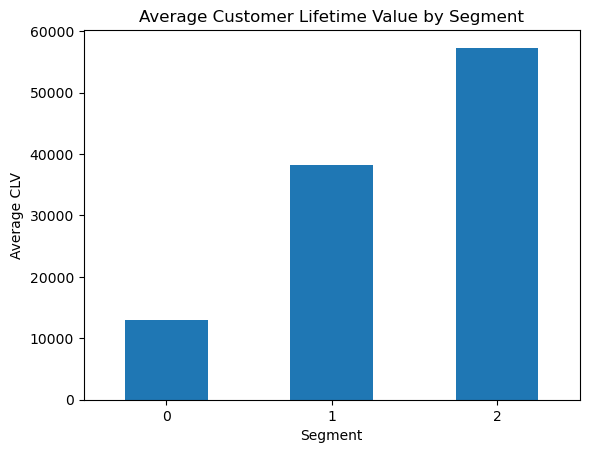

In [74]:
plt.figure()
df.groupby('segment')['customer_lifetime_value'].mean().plot(kind='bar')
plt.title("Average Customer Lifetime Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average CLV")
plt.show()

In [46]:
print(df.columns)

Index(['order_id', 'ship_date', 'ship_mode', 'customer_id', 'age', 'gender',
       'segment', 'country', 'region', 'category', 'sub-category',
       'product_id', 'product_name', 'sales', 'quantity', 'profit', 'returns',
       'payment_mode', 'customer_lifetime_value_x', 'avg_order_value',
       'purchase_frequency', 'customer_lifetime_value_y',
       'customer_lifetime_value'],
      dtype='object')


3.2 Average Order Value

In [16]:
aov = df.groupby('customer_id')['sales'].mean().reset_index()
aov.rename(columns={'sales': 'avg_order_value'}, inplace=True)

df = df.merge(aov, on='customer_id', how='left')

3.3 Purchase Frequency

In [17]:
freq = df.groupby('customer_id')['order_id'].count().reset_index()
freq.rename(columns={'order_id': 'purchase_frequency'}, inplace=True)

df = df.merge(freq, on='customer_id', how='left')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 200 non-null    object 
 1   ship_date                200 non-null    object 
 2   ship_mode                200 non-null    object 
 3   customer_id              200 non-null    object 
 4   age                      200 non-null    int64  
 5   gender                   200 non-null    object 
 6   segment                  200 non-null    object 
 7   country                  200 non-null    object 
 8   region                   200 non-null    object 
 9   category                 200 non-null    object 
 10  sub-category             200 non-null    object 
 11  product_id               200 non-null    object 
 12  product_name             200 non-null    object 
 13  sales                    200 non-null    float64
 14  quantity                 2

4 Customer Segmentation (K-Means)
4.1 Select Features

In [18]:
features = df[['customer_lifetime_value',
               'avg_order_value',
               'purchase_frequency']]

In [35]:
print(features)

     customer_lifetime_value  avg_order_value  purchase_frequency
0                    5702.23          5702.23                   1
1                   28487.81         28487.81                   1
2                   10362.79         10362.79                   1
3                   49627.96         49627.96                   1
4                   47558.47         47558.47                   1
..                       ...              ...                 ...
195                 72562.84         36281.42                   2
196                 21395.69         21395.69                   1
197                 43638.08         43638.08                   1
198                 30924.38         30924.38                   1
199                 43333.30         43333.30                   1

[200 rows x 3 columns]


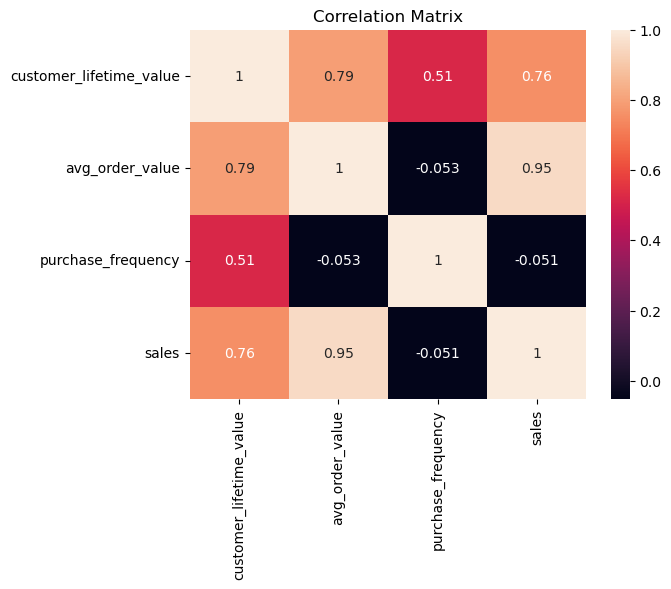

In [67]:
plt.figure()
sns.heatmap(df[['customer_lifetime_value',
                'avg_order_value',
                'purchase_frequency',
                'sales']].corr(),
            annot=True)
plt.title("Correlation Matrix")
plt.show()

4.2 Standardize Data

In [19]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

4.3 Elbow Method (Find Optimal K)

C:\Users\hp15s-dr3500tu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp15s-dr3500tu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp15s-dr3500tu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp15s-dr3500tu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

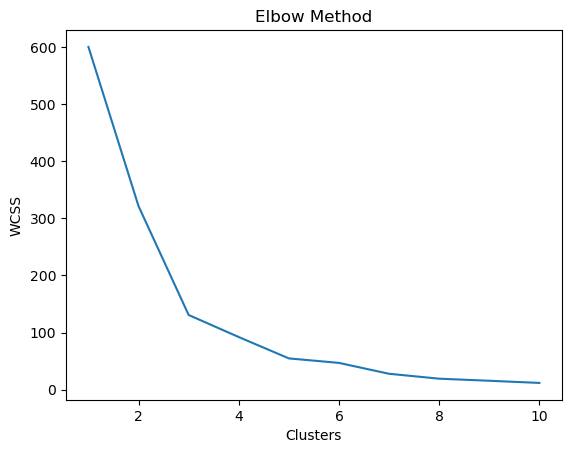

In [72]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

4.4 Apply K-Means

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['segment'] = kmeans.fit_predict(scaled_features)

C:\Users\hp15s-dr3500tu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


4.5 Segment Interpretation

In [21]:
df.groupby('segment')[['customer_lifetime_value',
                       'avg_order_value',
                       'purchase_frequency']].mean()

,customer_lifetime_value,avg_order_value,purchase_frequency
segment,,,
Consumer,26310.898028,22317.094648,1.169014
Corporate,33192.278689,28406.378033,1.196721
Home Office,31409.477059,26622.227500,1.205882


5.1 DEFINE FEATURES AND TARGET

In [22]:
X = df[['customer_lifetime_value',
        'avg_order_value',
        'purchase_frequency',
        'segment']]

y = df['sales']

5.2 Train-Test Split and Linear Regression

In [48]:
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

5.3 Evaluate Model

In [61]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [62]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Model Performance (R2 %):", r2 * 100)

RMSE: 5293.822273275515
MAE: 2077.470805474589
R2 Score: 0.8568114814974449
Model Performance (R2 %): 85.68114814974449


6 VISUALIZATION

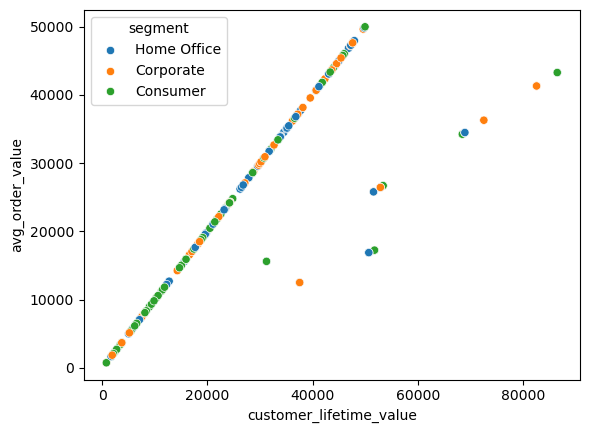

In [32]:
sns.scatterplot(data=df,
                x='customer_lifetime_value',
                y='avg_order_value',
                hue='segment')
plt.show()

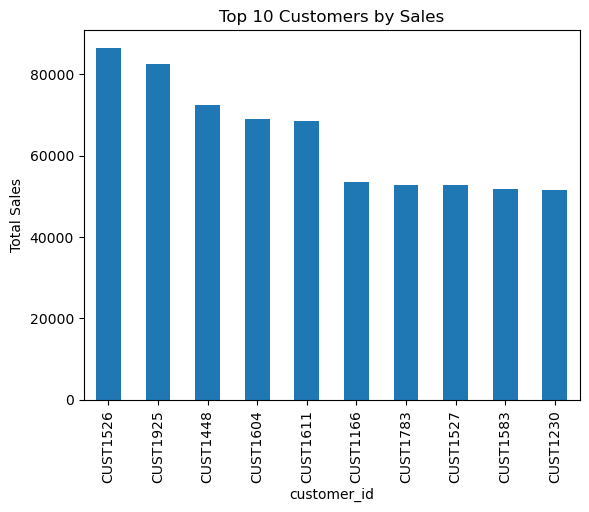

In [69]:
top_customers = df.groupby('customer_id')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.ylabel("Total Sales")
plt.show()

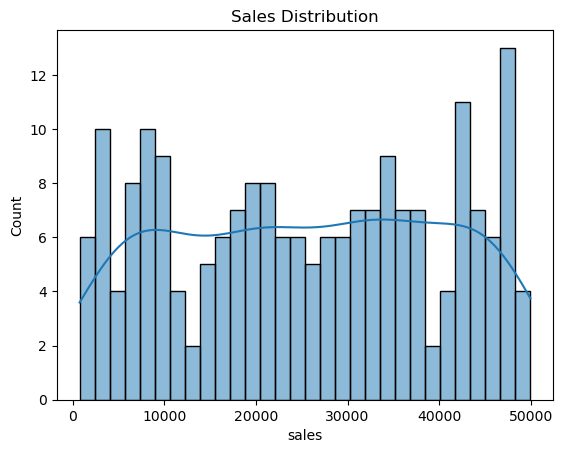

In [73]:
plt.figure()
sns.histplot(df['sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()